In [2]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# FICHIER STOPS

In [5]:
INPUT_PATH = "./data/stops.txt"
EXPORT_PATH = "./exports/stops_with_geom.csv"

In [6]:
def stops(input_path, output_path):
    df = pd.read_csv(input_path)
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df.stop_lon, df.stop_lat),
        crs="EPSG:4326"
    )
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    gdf.to_csv(output_path, index=False)
    print(f"Exported {len(gdf)} stops to {output_path}")


In [7]:
df = pd.read_csv("./data/stops.txt")

print("Colonnes:")
print(df.columns.tolist())



Colonnes:
['stop_id', 'stop_code', 'stop_name', 'stop_lat', 'stop_lon', 'zone_id', 'location_type', 'parent_station', 'stop_timezone', 'wheelchair_boarding']


In [8]:
print("\nTypes des donnees:")
print(df.dtypes)


Types des donnees:
stop_id                 object
stop_code               object
stop_name               object
stop_lat               float64
stop_lon               float64
zone_id                 object
location_type            int64
parent_station          object
stop_timezone           object
wheelchair_boarding      int64
dtype: object


In [9]:
print("premier lignes:")
print(df.head())

premier lignes:
  stop_id stop_code                          stop_name   stop_lat  stop_lon  \
0       1    ABBAT8                          Abattoirs  43.717886  7.284703   
1       2    ABBAT4                          Abattoirs  43.718399  7.284448   
2       3    ROSEL2                 Abbaye de Roseland  43.693389  7.228426   
3       4    ROSEL8                 Abbaye de Roseland  43.693219  7.228365   
4       5     ARSE4  Abbaye de Roseland / Napoléon III  43.688851  7.231361   

  zone_id  location_type parent_station stop_timezone  wheelchair_boarding  
0     NaN              0   place_101376           NaN                    1  
1     NaN              0   place_101376           NaN                    1  
2     NaN              0   place_096609           NaN                    0  
3     NaN              0   place_096609           NaN                    0  
4     NaN              0   place_096610           NaN                    0  


In [10]:
print("\n valeurs nulles:")
print(df.isna().sum())


 valeurs nulles:
stop_id                   0
stop_code              1651
stop_name                 0
stop_lat                  0
stop_lon                  0
zone_id                4481
location_type             0
parent_station         1672
stop_timezone          2813
wheelchair_boarding       0
dtype: int64


In [12]:
stops(INPUT_PATH, EXPORT_PATH)


Exported 4485 stops to ./exports/stops_with_geom.csv


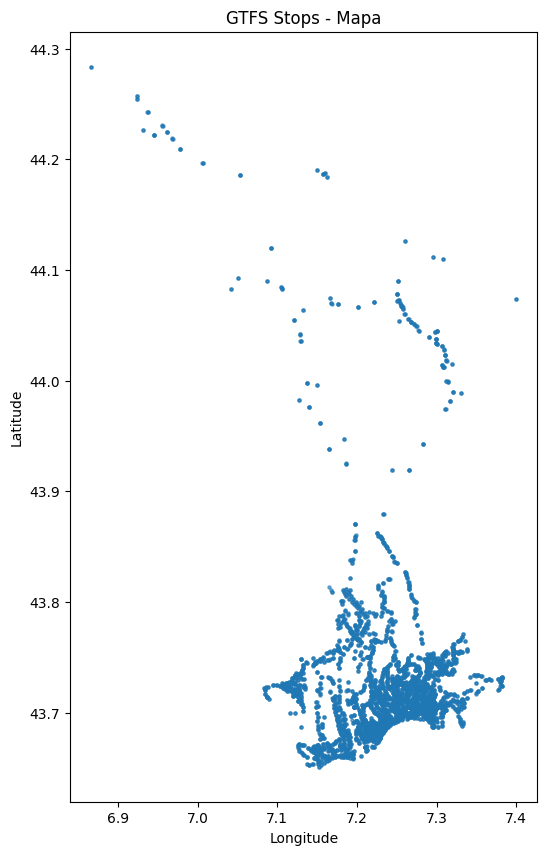

In [13]:
df = pd.read_csv(EXPORT_PATH)

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.stop_lon, df.stop_lat),
    crs="EPSG:4326"
)

gdf.plot(figsize=(10, 10), markersize=5, alpha=0.6)
plt.title("GTFS Stops - Mapa")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()



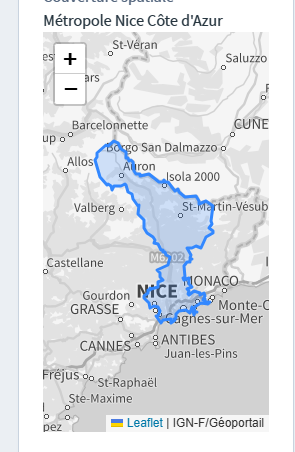

# TRIPS

In [3]:
trips_path = "./data/trips.txt"
routes_path = "./data/routes.txt"


In [4]:
trips_df = pd.read_csv(trips_path)
trips_df.head()

,route_id,service_id,trip_id,trip_headsign,trip_short_name,direction_id,shape_id,wheelchair_accessible,bikes_allowed
0,75,chouette:TimeTable:1a1f0115-0d34-40ed-ace6-30f...,4962940-75_R_97_7501_11:50-RESEAU2023-75-Diman...,Gare SNCF,4962940-75_R_97_7501_11:50-RESEAU2023-75-Diman...,1,750032,0,0
1,75,RESEAU2023-75-Dimanche-69-75,4962940-75_R_97_7501_11:50-RESEAU2023-75-Diman...,Gare SNCF,4962940-75_R_97_7501_11:50-RESEAU2023-75-Diman...,1,750032,0,0
2,75,RESEAU2023-75-Samedi-77-75,4962972-75_R_97_7501_17:45-RESEAU2023-75-Samed...,Gare SNCF,4962972-75_R_97_7501_17:45-RESEAU2023-75-Samed...,1,750032,0,0
3,40,RESEAU2023-40-Semaine-04-40,4350596-40_A_50_4001_14:53-RESEAU2023-40-Semai...,Collège Matisse,4350596-40_A_50_4001_14:53-RESEAU2023-40-Semai...,0,400009,0,0
4,62,RESEAU2023-62-Samedi-10-62,4336738-62_R_98_6203_18:10-RESEAU2023-62-Samed...,Magnan,4336738-62_R_98_6203_18:10-RESEAU2023-62-Samed...,1,620015,0,0


In [5]:
routes_df = pd.read_csv(routes_path)
routes_df.head()

,route_id,agency_id,route_short_name,route_long_name,route_type,route_url,route_color,route_text_color
0,05,lignes-d-azur,05,Rimiez Saint-George/Rimiez Les Sources - Deloy...,3,https://ftp.lignesdazur.com/ligne_5.pdf,3065AF,FFFFFF
1,06,lignes-d-azur,06,Magnan - La Madeleine,3,https://ftp.lignesdazur.com/ligne_6.pdf,2FA948,FFFFFF
2,07,lignes-d-azur,07,Port Lympia - Ariane / Général Saramito,3,https://ftp.lignesdazur.com/ligne_7.pdf,751D5D,FFFFFF
3,09,lignes-d-azur,09,Grand Arénas - Le Gué/Shopping promenade - Hal...,3,https://ftp.lignesdazur.com/ligne_9.pdf,EF7D00,FFFFFF
4,11,lignes-d-azur,11,Square Daudet - Vallon des Fleurs - Bella Vista,3,https://ftp.lignesdazur.com/ligne_11.pdf,9C3F8F,FFFFFF


In [12]:
# apres analyse des variables, merge entre routes et trips a trave de route_id

output_path = "./exports/trips_plus_routes.csv"


In [7]:
merged_routes_trips_df = trips_df.merge(
    routes_df[["route_id"]],
    on="route_id",
    how="left"
)

merged_routes_trips_df.head()

,route_id,service_id,trip_id,trip_headsign,trip_short_name,direction_id,shape_id,wheelchair_accessible,bikes_allowed
0,75,chouette:TimeTable:1a1f0115-0d34-40ed-ace6-30f...,4962940-75_R_97_7501_11:50-RESEAU2023-75-Diman...,Gare SNCF,4962940-75_R_97_7501_11:50-RESEAU2023-75-Diman...,1,750032,0,0
1,75,RESEAU2023-75-Dimanche-69-75,4962940-75_R_97_7501_11:50-RESEAU2023-75-Diman...,Gare SNCF,4962940-75_R_97_7501_11:50-RESEAU2023-75-Diman...,1,750032,0,0
2,75,RESEAU2023-75-Samedi-77-75,4962972-75_R_97_7501_17:45-RESEAU2023-75-Samed...,Gare SNCF,4962972-75_R_97_7501_17:45-RESEAU2023-75-Samed...,1,750032,0,0
3,40,RESEAU2023-40-Semaine-04-40,4350596-40_A_50_4001_14:53-RESEAU2023-40-Semai...,Collège Matisse,4350596-40_A_50_4001_14:53-RESEAU2023-40-Semai...,0,400009,0,0
4,62,RESEAU2023-62-Samedi-10-62,4336738-62_R_98_6203_18:10-RESEAU2023-62-Samed...,Magnan,4336738-62_R_98_6203_18:10-RESEAU2023-62-Samed...,1,620015,0,0


In [8]:
# merge pour considerer autres donnees route short et long_name

merged_routes_trips_names_df = trips_df.merge(
    routes_df[["route_id", "route_short_name", "route_long_name"]],
    on="route_id",
    how="left"
)

merged_routes_trips_names_df


,route_id,service_id,trip_id,trip_headsign,trip_short_name,direction_id,shape_id,wheelchair_accessible,bikes_allowed,route_short_name,route_long_name
0,75,chouette:TimeTable:1a1f0115-0d34-40ed-ace6-30f...,4962940-75_R_97_7501_11:50-RESEAU2023-75-Diman...,Gare SNCF,4962940-75_R_97_7501_11:50-RESEAU2023-75-Diman...,1,750032,0,0,75,Hameaux de la Costière - Gare Thiers
1,75,RESEAU2023-75-Dimanche-69-75,4962940-75_R_97_7501_11:50-RESEAU2023-75-Diman...,Gare SNCF,4962940-75_R_97_7501_11:50-RESEAU2023-75-Diman...,1,750032,0,0,75,Hameaux de la Costière - Gare Thiers
2,75,RESEAU2023-75-Samedi-77-75,4962972-75_R_97_7501_17:45-RESEAU2023-75-Samed...,Gare SNCF,4962972-75_R_97_7501_17:45-RESEAU2023-75-Samed...,1,750032,0,0,75,Hameaux de la Costière - Gare Thiers
3,40,RESEAU2023-40-Semaine-04-40,4350596-40_A_50_4001_14:53-RESEAU2023-40-Semai...,Collège Matisse,4350596-40_A_50_4001_14:53-RESEAU2023-40-Semai...,0,400009,0,0,40,Cimiez / Hôpital - Pasteur / Gassin
4,62,RESEAU2023-62-Samedi-10-62,4336738-62_R_98_6203_18:10-RESEAU2023-62-Samed...,Magnan,4336738-62_R_98_6203_18:10-RESEAU2023-62-Samed...,1,620015,0,0,62,Magnan - Fort Casal Colomars - Aspremont Village
...,...,...,...,...,...,...,...,...,...,...,...
23584,08,SETP2025-08-Dimanche-05-08,6493180-08_R_97_0806_23:30-SETP2025-08-Dimanch...,HOPITAL PASTEUR,6493180-08_R_97_0806_23:30-SETP2025-08-Dimanch...,1,080132,0,0,8+,Saint-Sylvestre - Palais des Expositions
23585,08,SETP2025-08-Dimanche-05-08,6493191-08_A_48_0806_06:40-SETP2025-08-Dimanch...,SAINT-SYLVESTRE,6493191-08_A_48_0806_06:40-SETP2025-08-Dimanch...,0,080131,0,0,8+,Saint-Sylvestre - Palais des Expositions
23586,08,chouette:TimeTable:aaf4fa27-670a-48b1-8af4-0cb...,6493210-08_R_97_0805_24:45-SETP2025-08-Dimanch...,HOPITAL PASTEUR,6493210-08_R_97_0805_24:45-SETP2025-08-Dimanch...,1,080132,0,0,8+,Saint-Sylvestre - Palais des Expositions
23587,08,SETP2025-08-Dimanche-05-08,6493230-08_A_48_0803_06:10-SETP2025-08-Dimanch...,SAINT-SYLVESTRE,6493230-08_A_48_0803_06:10-SETP2025-08-Dimanch...,0,080131,0,0,8+,Saint-Sylvestre - Palais des Expositions


In [13]:
os.makedirs(os.path.dirname(output_path), exist_ok=True)
merged_routes_trips_names_df.to_csv(output_path, index=False)

print("donnees exportes ok")

donnees exportes ok
